<a href="https://colab.research.google.com/github/Katab-sawan/Dissertation/blob/Linear-Regression-Models/NVDA_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_9773/459986837.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("NVDA", start="2012-01-01")
[*********************100%***********************]  1 of 1 completed


Linear Regression Performance (NVDA)
MAE: 0.644798266450532
RMSE: 0.9772140976726328
R² Score: 0.9997517021152641


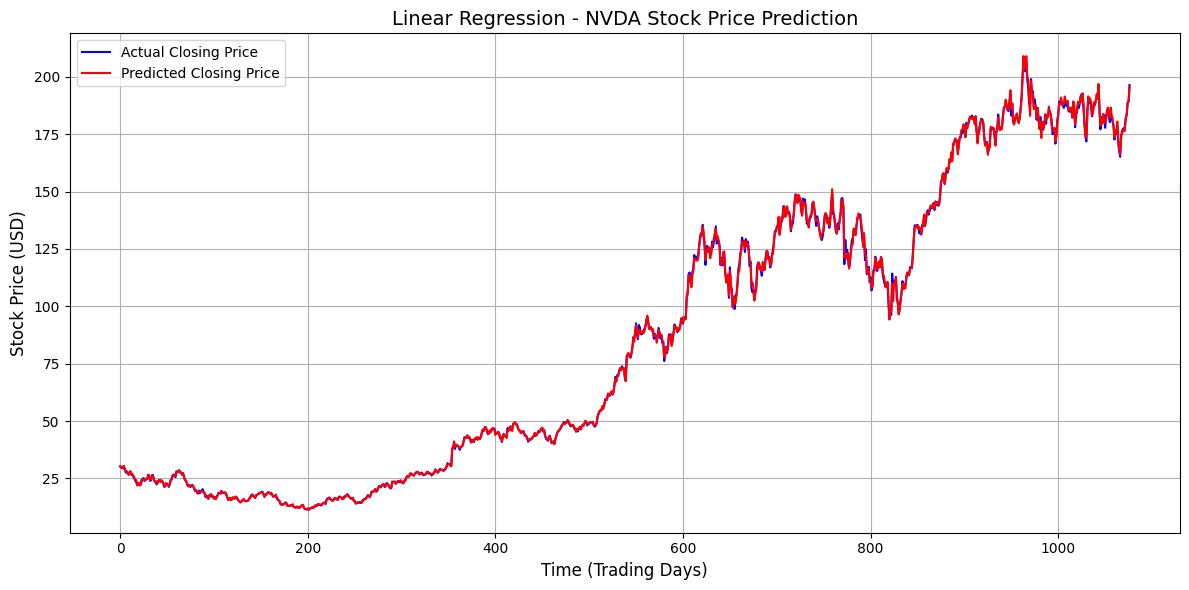

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = yf.download("NVDA", start="2012-01-01")

df = df[['Open', 'High', 'Low', 'Volume', 'Close']]

df.dropna(inplace=True)

X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=False
)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance (NVDA)")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)



plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual Closing Price", color='blue')
plt.plot(y_pred, label="Predicted Closing Price", color='red')

plt.title("Linear Regression - NVDA Stock Price Prediction", fontsize=14)
plt.xlabel("Time (Trading Days)", fontsize=12)
plt.ylabel("Stock Price (USD)", fontsize=12)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

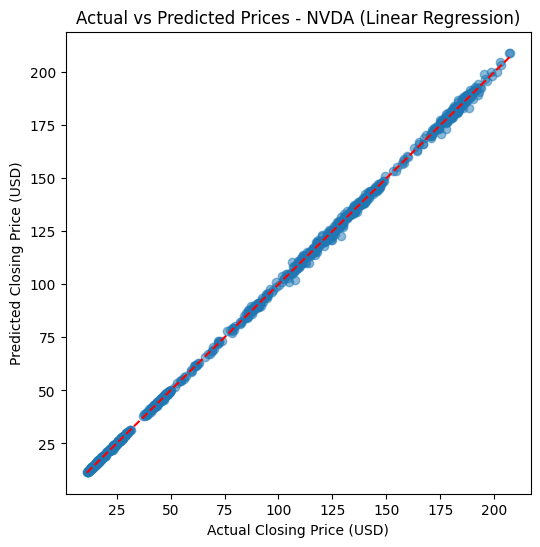

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Closing Price (USD)")
plt.ylabel("Predicted Closing Price (USD)")
plt.title("Actual vs Predicted Prices - NVDA (Linear Regression)")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.show()

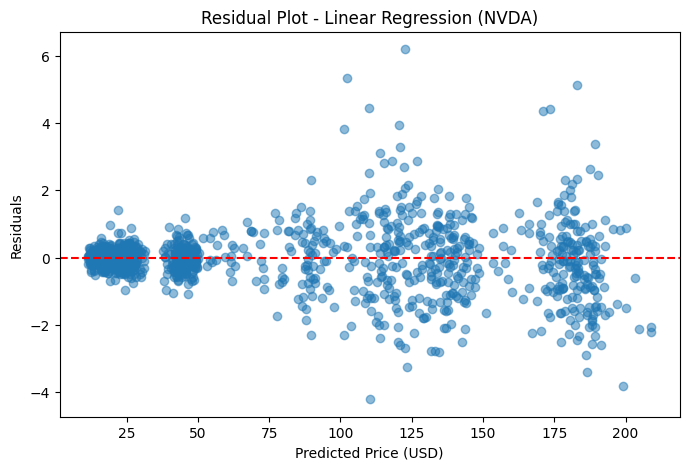

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price (USD)")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression (NVDA)")
plt.show()

In [ ]:

mse = rmse**2
print("MSE:", mse)

MSE: 0.9549473926901378
